# Creation of Dataset

### Bug:

If .ipynb-checkpoints in dataset:

``find . -type d -name ".ipynb_checkpoints" -exec dirname {} \;``

and delete these.

## Download datasets

In [20]:
pip install kagglehub

Looking in indexes: https://nexus.iisys.de/repository/ki-awz-pypi-group/simple, https://pypi.org/simple

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

sbc_path = kagglehub.dataset_download("sylshaw/streetview-by-country")

In [1]:
import kagglehub

gsv_path = kagglehub.dataset_download("paulchambaz/google-street-view")

/home/jovyan/CountryGuessr/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 600M/600M [00:23<00:00, 27.1MB/s] 

Extracting files...


In [23]:
print(sbc_path)
print(gsv_path)

/home/jovyan/.cache/kagglehub/datasets/sylshaw/streetview-by-country/versions/2
/home/jovyan/.cache/kagglehub/datasets/paulchambaz/google-street-view/versions/1


# Format to following structure:

**IMPORTANT:** All images have to be in ``.jpg``
```
data/
├── US/
│   ├── 0001.jpg  
│   ├── 0002.jpg
│   └── ...
├── DE/
│   ├── 0001.jpg  
│   ├── 0002.jpg
│   └── ...
├── ...
```

In [24]:
DATA_DIR = Path("./data")
os.makedirs(DATA_DIR, exist_ok=True)

### Format Streetview-By-Country

In [29]:
sbc_data_path = Path(os.path.join(sbc_path, "streetview_images"))

for country_dir in sbc_data_path.iterdir():
    if not country_dir.is_dir():
        continue
    country_code = country_dir.name
    target_dir = DATA_DIR / country_code
    os.makedirs(target_dir, exist_ok=True)

    existing_count = len(list(target_dir.glob("*.jpg")))
    next_index = existing_count

    for img_file in country_dir.iterdir():
        if img_file.suffix.lower() == ".jpg":
            new_name = f"{next_index:04d}{img_file.suffix.lower()}"
            dst = target_dir / new_name
            shutil.move(img_file, dst)
            next_index += 1

    if not any(country_dir.iterdir()):
        country_dir.rmdir()

print("Done")

Processing images: 112it [01:15,  1.47it/s]


### Format Google-Street-View

In [31]:
import os
import pandas as pd
import reverse_geocoder as rg
from pathlib import Path

gsv_data_path = Path(os.path.join(gsv_path, "dataset"))
gsv_df = pd.read_csv(os.path.join(gsv_data_path, "coords.csv"), header=None, names=["lat", "lon"])

# Convert lat/lon to country_code from coords.csv
coords = [(row['lat'], row['lon']) for idx, row in gsv_df.iterrows() 
          if not (pd.isna(row['lat']) or pd.isna(row['lon']))]
results = rg.search(coords, mode=1)

for i, result in enumerate(results):
    lat, lon = coords[i]
    mask = (abs(gsv_df['lat'] - lat) < 1e-6) & (abs(gsv_df['lon'] - lon) < 1e-6)
    if mask.any():
        idx = mask.idxmax()
        gsv_df.loc[idx, 'country_code'] = result["cc"].upper()
    
gsv_df[['lat', 'lon', 'country_code']].to_csv(
    os.path.join(gsv_data_path, "coords.csv"), index=False, header=True
)
gsv_df.head()

,lat,lon,country_code
0,20.824885,-98.499517,MX
1,-3.451752,-54.563937,BR
2,-23.496464,-47.460542,BR
3,-16.548678,-72.852778,PE
4,-35.010870,140.064397,AU


In [35]:
gsv_df = pd.read_csv(os.path.join(gsv_data_path, "coords.csv"))

for country_code, group in gsv_df.groupby("country_code"):
    target_dir = DATA_DIR / country_code
    os.makedirs(target_dir, exist_ok=True)

    existing_count = len(list(target_dir.glob("*.jpg")))
    next_index = existing_count

    for idx, row in group.iterrows():
        img_name = f"{int(idx)}.png"
        src_img = gsv_data_path / img_name

        with Image.open(src_img) as img:
            if img.mode != "RGB":
                img = img.convert("RGB")

            img_buffer = io.BytesIO()
            img.save(img_buffer, format="JPEG", quality=95)
            img_buffer.seek(0)

        new_name = f"{next_index:04d}.jpg"
        dst = target_dir / new_name

        with open(dst, 'wb') as f:
            f.write(img_buffer.getvalue())

        src_img.unlink()
        next_index += 1

print("Done")

Processing countries: 100%|██████████| 105/105 [01:01<00:00,  1.70country/s]

Done


## Drop / Balance countries

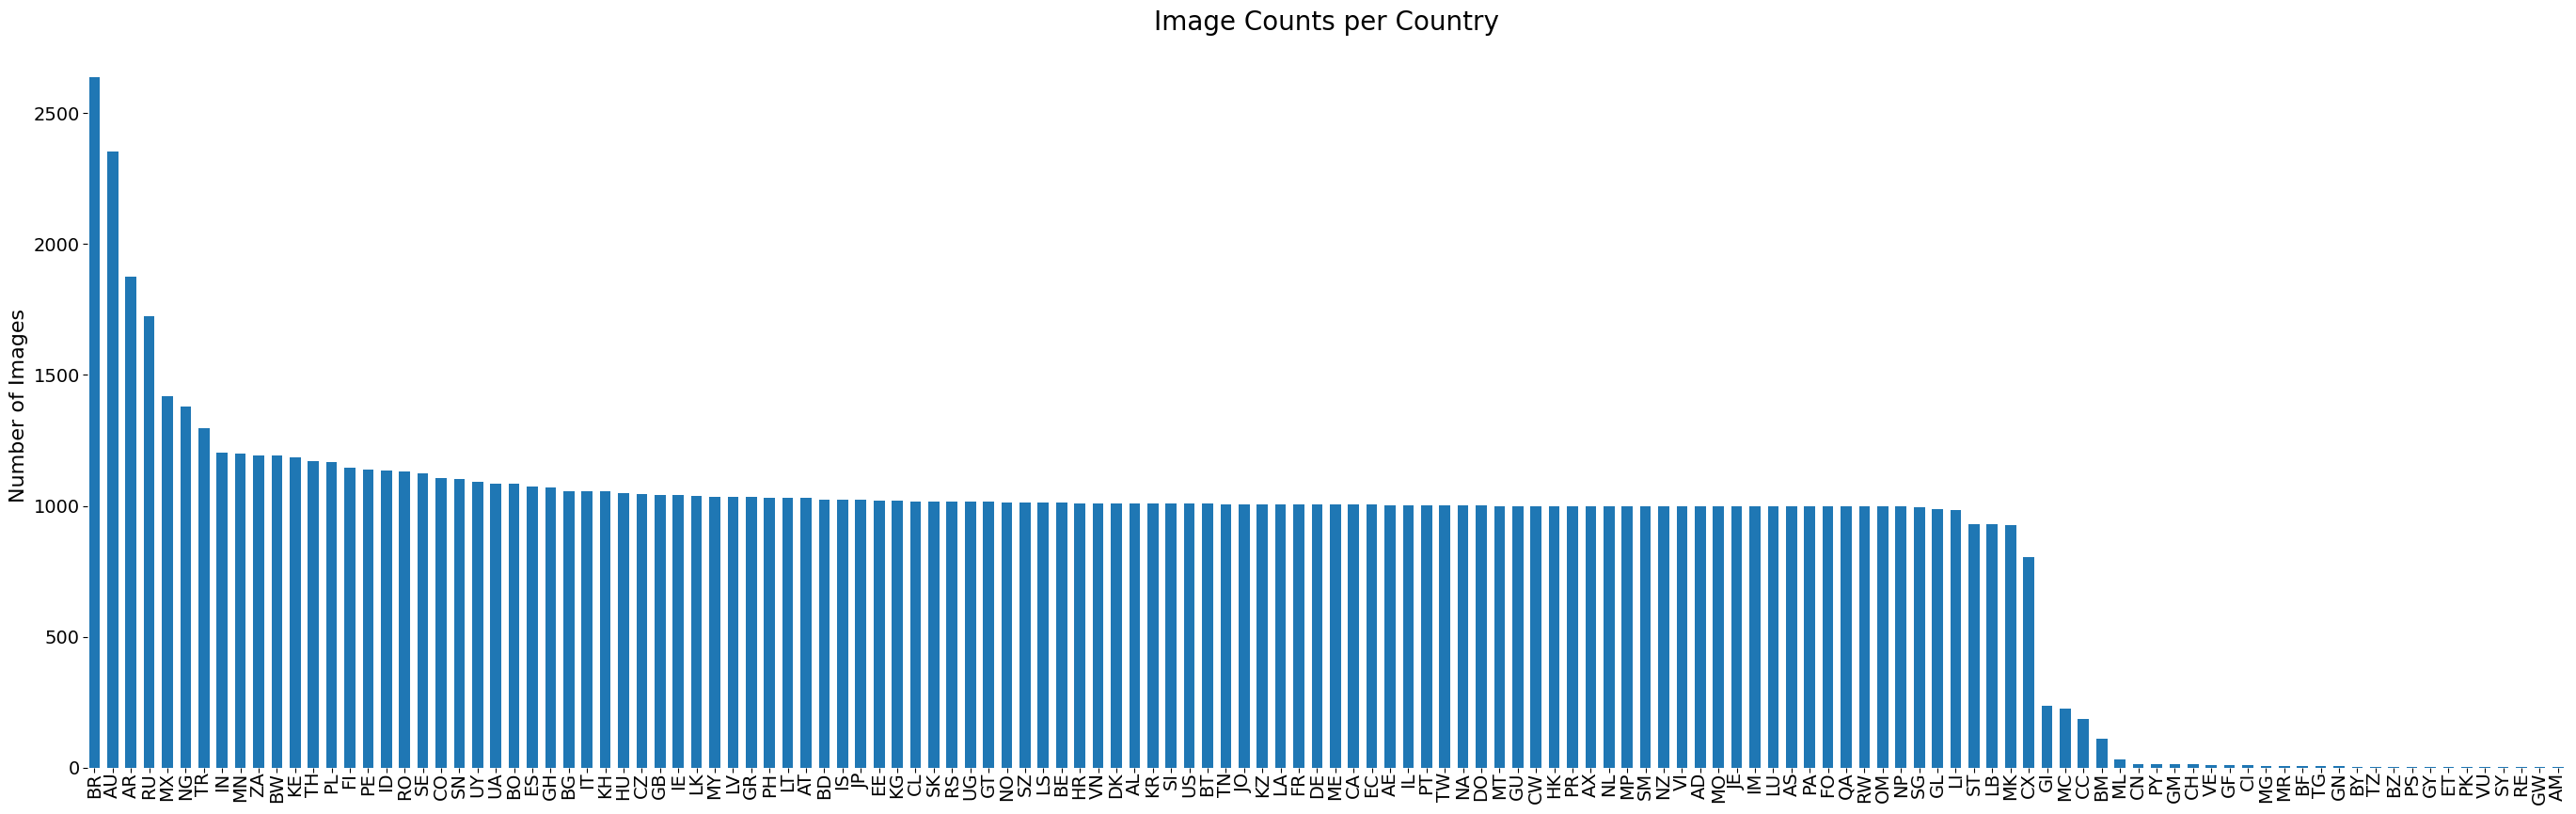

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

country_counts = Counter()

for country_dir in DATA_DIR.iterdir():
    if not country_dir.is_dir():
        continue
        
    country_code = country_dir.name
    count = sum(1 for f in country_dir.glob('*') 
                if f.suffix.lower() == ".jpg")
    country_counts[country_code] = count

sorted_countries = sorted(country_counts.items(), key=lambda x: x[1], reverse=True)
countries = [code for code, count in sorted_countries]
counts = [count for code, count in sorted_countries]

fig, ax = plt.subplots(figsize=(max(14, len(countries) * 0.25), 10))

x_pos = np.arange(len(countries))
bars = ax.bar(x_pos, counts, width=0.6)

ax.set_xlim(-0.4, len(countries) - 0.6)
ax.set_xticks(x_pos)
ax.set_xticklabels(countries, rotation=90, fontsize=6, ha='center')
ax.set_ylabel('Number of Images', fontsize=16)
ax.set_title('Image Counts per Country', fontsize=20, pad=10)

sns.despine(ax=ax, left=True, bottom=True, trim=True)
ax.tick_params(axis='x', pad=0, labelsize=14)
ax.tick_params(axis='y', pad=2, labelsize=14)

plt.show()

In [92]:
MIN_THRESHOLD = 500
MAX_THRESHOLD = 2000

country_counts = Counter()
for country_dir in DATA_DIR.iterdir():
    if not country_dir.is_dir():
        continue
    count = len(list(country_dir.glob("*.jpg")))
    country_counts[country_dir.name] = count

deleted_countries = 0
for country_dir in list(DATA_DIR.iterdir()):
    if not country_dir.is_dir():
        continue
        
    count = len(list(country_dir.glob("*.jpg")))
    
    if count < MIN_THRESHOLD:
        shutil.rmtree(country_dir)
        print(f"DELETED {country_dir.name}: {count} images (< {MIN_THRESHOLD})")
        deleted_countries += 1

balanced_countries = 0
for country_dir in DATA_DIR.iterdir():
    if not country_dir.is_dir():
        continue
        
    images = sorted(country_dir.glob("*.jpg"))
    count = len(images)
    
    if count > MAX_THRESHOLD:
        excess_images = images[MAX_THRESHOLD:]
        for img in excess_images:
            img.unlink()
        
        print(f"BALANCED {country_dir.name}: {count} -> {MAX_THRESHOLD} images")
        balanced_countries += 1

final_counts = Counter()
for country_dir in DATA_DIR.iterdir():
    if country_dir.is_dir():
        final_counts[country_dir.name] = len(list(country_dir.glob("*.jpg")))

total_final = sum(final_counts.values())
print(f"   Countries: {len(country_counts)} → {len(final_counts)}")
print(f"   Images:    {sum(country_counts.values())} → {total_final}")
print(f"   Deleted:   {deleted_countries} countries")
print(f"   Balanced:  {balanced_countries} countries")

   Countries: 107 → 107
   Images:    114817 → 114817
   Deleted:   0 countries
   Balanced:  0 countries


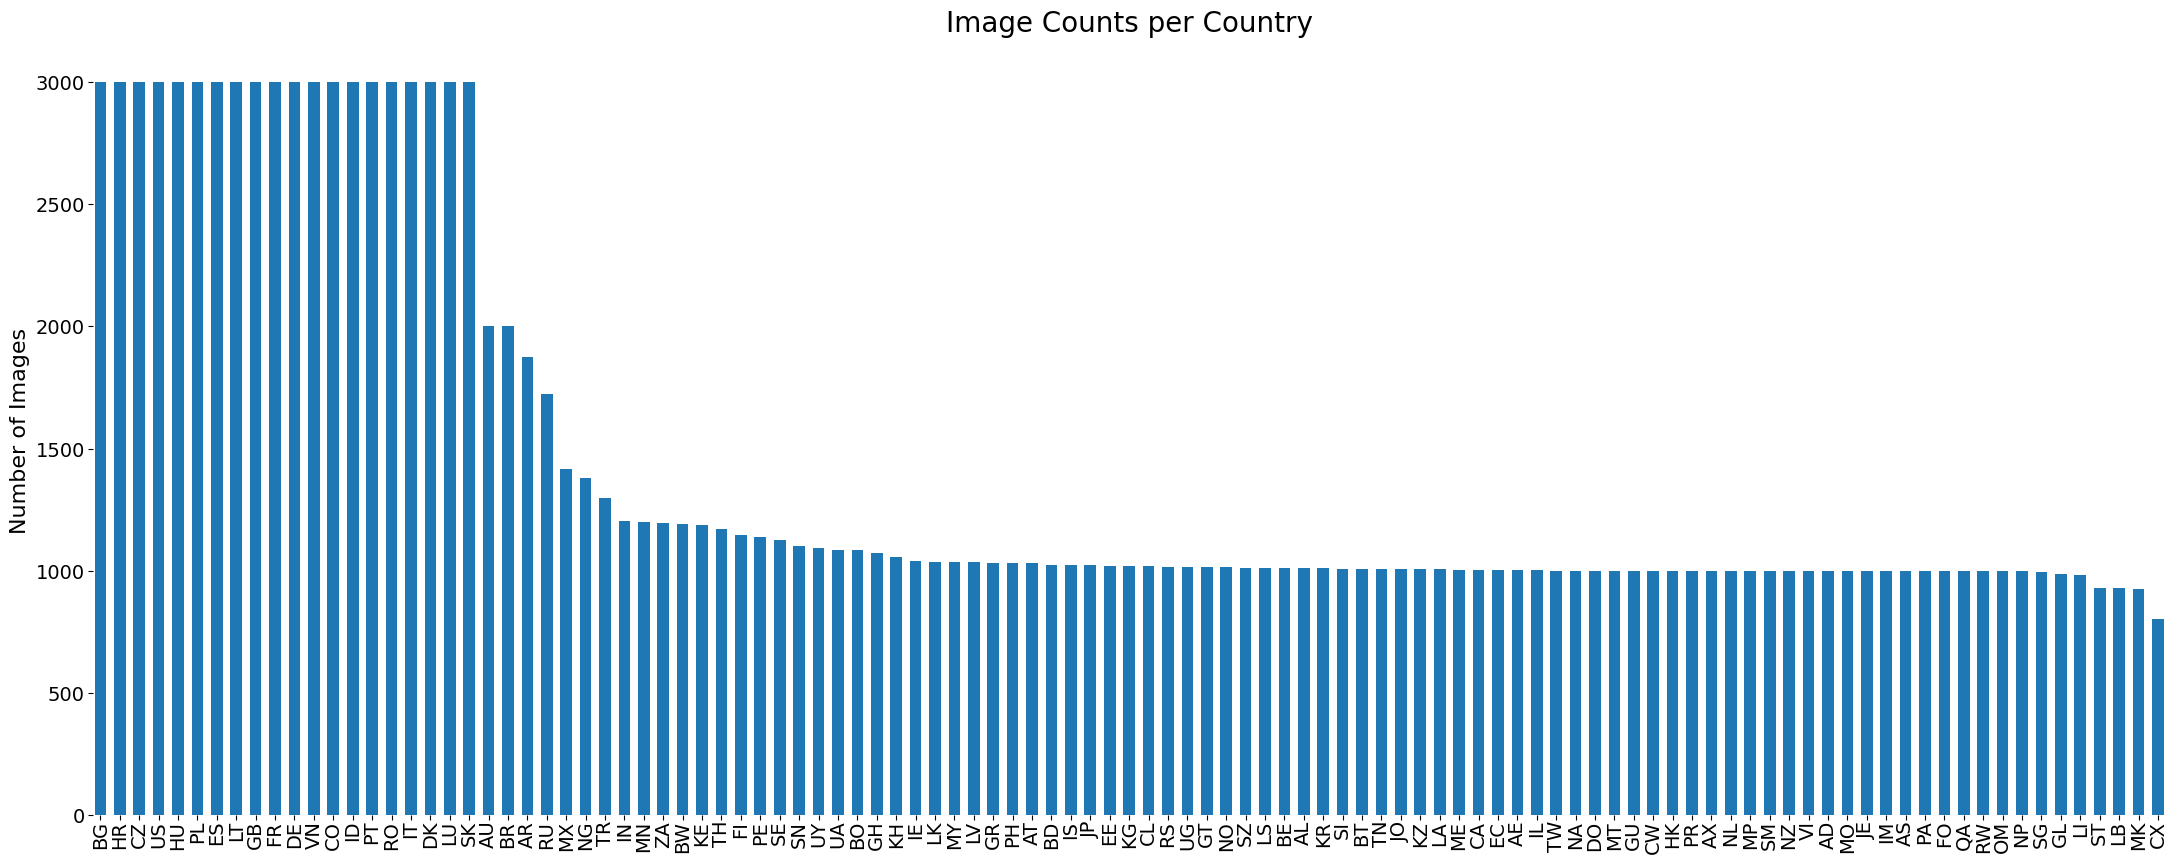

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

country_counts = Counter()

for country_dir in DATA_DIR.iterdir():
    if not country_dir.is_dir():
        continue
        
    country_code = country_dir.name
    count = sum(1 for f in country_dir.glob('*') 
                if f.suffix.lower() == ".jpg")
    country_counts[country_code] = count

sorted_countries = sorted(country_counts.items(), key=lambda x: x[1], reverse=True)
countries = [code for code, count in sorted_countries]
counts = [count for code, count in sorted_countries]

fig, ax = plt.subplots(figsize=(max(14, len(countries) * 0.25), 10))

x_pos = np.arange(len(countries))
bars = ax.bar(x_pos, counts, width=0.6)

ax.set_xlim(-0.4, len(countries) - 0.6)
ax.set_xticks(x_pos)
ax.set_xticklabels(countries, rotation=90, fontsize=6, ha='center')
ax.set_ylabel('Number of Images', fontsize=16)
ax.set_title('Image Counts per Country', fontsize=20, pad=10)

sns.despine(ax=ax, left=True, bottom=True, trim=True)
ax.tick_params(axis='x', pad=0, labelsize=14)
ax.tick_params(axis='y', pad=2, labelsize=14)

plt.show()

## Countries with poor performance

In [65]:
countries = [
    "Italy",
    "Czechia",
    "France",
    "Lithuania",
    "Slovakia",
    "Spain",
    "Croatia",
    "Hungary",
    "Portugal",
    "Poland",
    "United Kingdom",
    "Denmark",
    "United States",
    "Romania",
    "Colombia",
    "Viet Nam",
    "Indonesia",
    "Bulgaria",
    "Germany",
    "Luxembourg"
]

## Add images to poor performing countries

In [11]:
import kagglehub

geoguessr_path = kagglehub.dataset_download("ubitquitin/geolocation-geoguessr-images-50k")

In [10]:
import os

geo_data_path = os.path.join(geoguessr_path, "compressed_dataset")
all_countries = [d for d in os.listdir(geo_data_path) if os.path.isdir(os.path.join(geo_data_path, d))]

filtered_countries = [c for c in all_countries if c.lower() in [country.lower() for country in countries]]

filtered_paths = [os.path.join(geo_data_path, c) for c in filtered_countries]

print("Filtered countries:", filtered_countries)
print("Paths:", filtered_paths) 

Filtered countries: ['Spain', 'Indonesia', 'United States', 'Germany', 'Denmark', 'Hungary', 'Croatia', 'Poland', 'Colombia', 'Slovakia', 'Romania', 'Portugal', 'Luxembourg', 'Czechia', 'Italy', 'Lithuania', 'Bulgaria', 'United Kingdom', 'France']
Paths: ['/home/jovyan/.cache/kagglehub/datasets/ubitquitin/geolocation-geoguessr-images-50k/versions/1/compressed_dataset/Spain', '/home/jovyan/.cache/kagglehub/datasets/ubitquitin/geolocation-geoguessr-images-50k/versions/1/compressed_dataset/Indonesia', '/home/jovyan/.cache/kagglehub/datasets/ubitquitin/geolocation-geoguessr-images-50k/versions/1/compressed_dataset/United States', '/home/jovyan/.cache/kagglehub/datasets/ubitquitin/geolocation-geoguessr-images-50k/versions/1/compressed_dataset/Germany', '/home/jovyan/.cache/kagglehub/datasets/ubitquitin/geolocation-geoguessr-images-50k/versions/1/compressed_dataset/Denmark', '/home/jovyan/.cache/kagglehub/datasets/ubitquitin/geolocation-geoguessr-images-50k/versions/1/compressed_dataset/Hung

In [12]:
from PIL import Image
import os
import glob
from pathlib import Path

def center_crop(img_path):
    with Image.open(img_path) as img:
        img = img.convert("RGB")
        w, h = img.size
        size = 640
        left = (w - size) // 2
        top = (h - size) // 2
        right = left + size
        bottom = top + size
        cropped = img.crop((left, top, right, bottom))
        cropped.save(img_path, "JPEG", quality=95)

total_cropped = 0
for country_path in filtered_paths:
    country_name = os.path.basename(country_path)
    print(country_name)

    img_files = glob.glob(os.path.join(country_path, "*.jpg"))
    for img_file in img_files:
        center_crop(img_file)
        total_cropped += 1

    print(f"  Done: {len(img_files)} images")

print(f"All {total_cropped} images cropped to 640x640!")

Spain
  Done: 1075 images
Indonesia
  Done: 288 images
United States
  Done: 12014 images
Germany
  Done: 698 images
Denmark
  Done: 198 images
Hungary
  Done: 168 images
Croatia
  Done: 129 images
Poland
  Done: 863 images
Colombia
  Done: 251 images
Slovakia
  Done: 108 images
Romania
  Done: 346 images
Portugal
  Done: 242 images
Luxembourg
  Done: 25 images
Czechia
  Done: 257 images
Italy
  Done: 789 images
Lithuania
  Done: 140 images
Bulgaria
  Done: 217 images
United Kingdom
  Done: 2484 images
France
  Done: 3573 images
All 23865 images cropped to 640x640!


In [37]:
import pycountry
import os
import shutil
from pathlib import Path

for path in filtered_paths:
    country_dir = Path(path)
    country_name = country_dir.name
    
    country = pycountry.countries.get(name=country_name)
    country_code = country.alpha_2

    target_dir = DATA_DIR / country_code
    os.makedirs(target_dir, exist_ok=True)

    existing_count = len(list(target_dir.glob("*.jpg")))
    next_index = existing_count

    for img_file in country_dir.iterdir():
        if img_file.suffix.lower() == ".jpg":
            new_name = f"{next_index:04d}{img_file.suffix.lower()}"
            dst = target_dir / new_name
            shutil.move(img_file, dst)
            next_index += 1

    if not any(country_dir.iterdir()):
        country_dir.rmdir()

print("Done")

Done


## Augment images of poor performing countries

In [61]:
from pathlib import Path
from PIL import Image, ImageEnhance
import pycountry
import random
import numpy as np
from collections import defaultdict

TARGET_COUNT = 3000

def augment_image(img):
    angle = random.uniform(-15, 15)
    img = img.rotate(angle, resample=Image.BICUBIC, expand=False)

    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))

    return img

def pad_to_4digits(n):
    return f"{n:04d}.jpg"

for country_name in countries:
    country = pycountry.countries.get(name=country_name)
    country_code = country.alpha_2
    print(country_code)

    country_dir = DATA_DIR / country_code

    images = sorted(country_dir.glob("*.jpg"))
    current_count = len(images)

    needed = TARGET_COUNT - current_count
    augmented_count = 0

    while augmented_count < needed:
        orig_img_path = random.choice(images)
        with Image.open(orig_img_path) as orig_img:
            orig_img = orig_img.convert("RGB")
            aug_img = augment_image(orig_img)
        
        next_idx = current_count + augmented_count + 1
        aug_path = country_dir / pad_to_4digits(next_idx)
        
        aug_img.save(aug_path, "JPEG", quality=95)
        augmented_count += 1
        
        if augmented_count % 100 == 0:
            print(f"  Augmented {augmented_count}/{needed} for {country_code}")
    
    print(f"{country_code}: Augmented {augmented_count} images → total {current_count + augmented_count}")

print("Augmentation complete! Re-run your balance plot.")

IT
  Augmented 100/1903 for IT
  Augmented 200/1903 for IT
  Augmented 300/1903 for IT
  Augmented 400/1903 for IT
  Augmented 500/1903 for IT
  Augmented 600/1903 for IT
  Augmented 700/1903 for IT
  Augmented 800/1903 for IT
  Augmented 900/1903 for IT
  Augmented 1000/1903 for IT
  Augmented 1100/1903 for IT
  Augmented 1200/1903 for IT
  Augmented 1300/1903 for IT
  Augmented 1400/1903 for IT
  Augmented 1500/1903 for IT
  Augmented 1600/1903 for IT
  Augmented 1700/1903 for IT
  Augmented 1800/1903 for IT
  Augmented 1900/1903 for IT
IT: Augmented 1903 images → total 5000
CZ
  Augmented 100/3699 for CZ
  Augmented 200/3699 for CZ
  Augmented 300/3699 for CZ
  Augmented 400/3699 for CZ
  Augmented 500/3699 for CZ
  Augmented 600/3699 for CZ
  Augmented 700/3699 for CZ
  Augmented 800/3699 for CZ
  Augmented 900/3699 for CZ
  Augmented 1000/3699 for CZ
  Augmented 1100/3699 for CZ
  Augmented 1200/3699 for CZ
  Augmented 1300/3699 for CZ
  Augmented 1400/3699 for CZ
  Augmented 1500

In [64]:
print(countries)

['US', 'BG', 'HR', 'CZ', 'HU', 'PL', 'ES', 'LT', 'GB', 'FR', 'DE', 'VN', 'CO', 'ID', 'PT', 'RO', 'IT', 'DK', 'LU', 'SK', 'AU', 'BR', 'AR', 'RU', 'MX', 'NG', 'TR', 'IN', 'MN', 'ZA', 'BW', 'KE', 'TH', 'FI', 'PE', 'SE', 'SN', 'UY', 'UA', 'BO', 'GH', 'KH', 'IE', 'LK', 'MY', 'LV', 'GR', 'PH', 'AT', 'BD', 'IS', 'JP', 'EE', 'KG', 'CL', 'RS', 'UG', 'GT', 'NO', 'SZ', 'LS', 'BE', 'AL', 'KR', 'SI', 'BT', 'TN', 'JO', 'KZ', 'LA', 'ME', 'CA', 'EC', 'AE', 'IL', 'TW', 'NA', 'DO', 'MT', 'GU', 'CW', 'HK', 'PR', 'AX', 'NL', 'MP', 'SM', 'NZ', 'VI', 'AD', 'MO', 'JE', 'IM', 'AS', 'PA', 'FO', 'QA', 'RW', 'OM', 'NP', 'SG', 'GL', 'LI', 'ST', 'LB', 'MK', 'CX']


If augmented too much images, reduce again

In [67]:
from pathlib import Path

TARGET_COUNT = 3000

deleted_total = 0
for country_name in countries:
    country = pycountry.countries.get(name=country_name)
    country_code = country.alpha_2

    country_dir = DATA_DIR / country_code

    images = sorted(country_dir.glob("*.jpg"))
    current_count = len(images)

    if current_count <= TARGET_COUNT:
        print(f"{country_code}: {current_count} <= {TARGET_COUNT}, no deletion.")
        continue
    
    excess_images = images[TARGET_COUNT:]
    for img_path in excess_images:
        img_path.unlink()
        deleted_total += 1
    
    print(f"{country_code}: Deleted {len(excess_images)} → now {TARGET_COUNT} images.")

print(f"Trim complete! Deleted {deleted_total} total images. Replot balance.")

IT: Deleted 2000 → now 3000 images.
CZ: Deleted 2000 → now 3000 images.
FR: Deleted 2000 → now 3000 images.
LT: Deleted 2000 → now 3000 images.
SK: Deleted 2000 → now 3000 images.
ES: Deleted 2000 → now 3000 images.
HR: Deleted 2000 → now 3000 images.
HU: Deleted 2000 → now 3000 images.
PT: Deleted 2000 → now 3000 images.
PL: Deleted 2000 → now 3000 images.
GB: Deleted 2000 → now 3000 images.
DK: Deleted 2000 → now 3000 images.
US: Deleted 5000 → now 3000 images.
RO: Deleted 2000 → now 3000 images.
CO: Deleted 2000 → now 3000 images.
VN: Deleted 2000 → now 3000 images.
ID: Deleted 2000 → now 3000 images.
BG: Deleted 2000 → now 3000 images.
DE: Deleted 2000 → now 3000 images.
LU: Deleted 2000 → now 3000 images.
Trim complete! Deleted 43000 total images. Replot balance.
